# 09 — Optimal Design Theory
**References:** Kiefer (1959) · Kiefer & Wolfowitz (1960) · Atkinson, Donev & Tobias (2007) · Fedorov (1972)

## Narrative thread
```
Why optimal design -> Information matrix -> D-optimality -> Coordinate exchange algorithm -> Applications
```

## Why optimal design?

Classical designs (factorial, RCBD, CCD) require a **fixed structure** — equal replication, orthogonality, specific run counts.

**When classical designs don't fit:**
- Mixture constraints (e.g., ingredients must sum to 1)
- Irregular experimental regions (some factor combinations impossible)
- Non-standard models (non-linear, non-polynomial)
- Exact run count required (budget = 12 runs, but $2^4=16$)

**Optimal design** finds the allocation of experimental runs that maximizes
some function of the **Fisher information matrix** $M(\xi) = X^\top X$.

## The information matrix

For a linear model $y = X\beta + \varepsilon$, the covariance of $\hat{\beta}$:
$$\text{Var}(\hat{\beta}) = \sigma^2 (X^\top X)^{-1}$$

A "good" design makes $(X^\top X)$ large (so $(X^\top X)^{-1}$ is small).

## Optimality criteria

**D-optimality:** maximize $\det(X^\top X)$ — minimize the volume of the confidence ellipsoid for $\hat{\beta}$.
$$\xi^* = \arg\max_\xi |M(\xi)|$$

**A-optimality:** minimize $\text{tr}[(X^\top X)^{-1}]$ — minimize average variance of $\hat{\beta}$.

**I-optimality (V-optimality):** minimize $\int \text{Var}(\hat{y}(x)) d\mu(x)$ — minimize average prediction variance over the design region.

**G-optimality:** minimize $\max_x \text{Var}(\hat{y}(x))$ — minimize the worst-case prediction variance.

**Equivalence theorem (Kiefer & Wolfowitz, 1960):** $\xi^*$ is D-optimal iff it is G-optimal.

## D-efficiency

How efficient is a given design relative to the D-optimal design?

$$D\text{-efficiency} = \left( \frac{|M(\xi)|}{|M(\xi^*)|} \right)^{1/p} \times 100\%$$

where $p$ = number of parameters. A $D$-efficiency of 95% means the design is nearly optimal.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

Running coordinate exchange algorithm...

D-criterion comparison (n_runs=12):
  Full 2^3 (8 runs):        det = 2097152.0
  Random design (mean/max): det = 4346347.5 / 25165824.0
  Coordinate exchange opt:  det = 25165824.0

D-efficiency vs best random: 100.0%

Optimal 12-run design:
  x1   x2   x3  Run
 1.0 -1.0  1.0    1
-1.0  1.0  1.0    2
-1.0 -1.0 -1.0    3
-1.0 -1.0 -1.0    4
-1.0  1.0 -1.0    5
 1.0  1.0  1.0    6
 1.0 -1.0 -1.0    7
 1.0 -1.0 -1.0    8
 1.0  1.0 -1.0    9
-1.0 -1.0  1.0   10
-1.0  1.0 -1.0   11
 1.0  1.0 -1.0   12


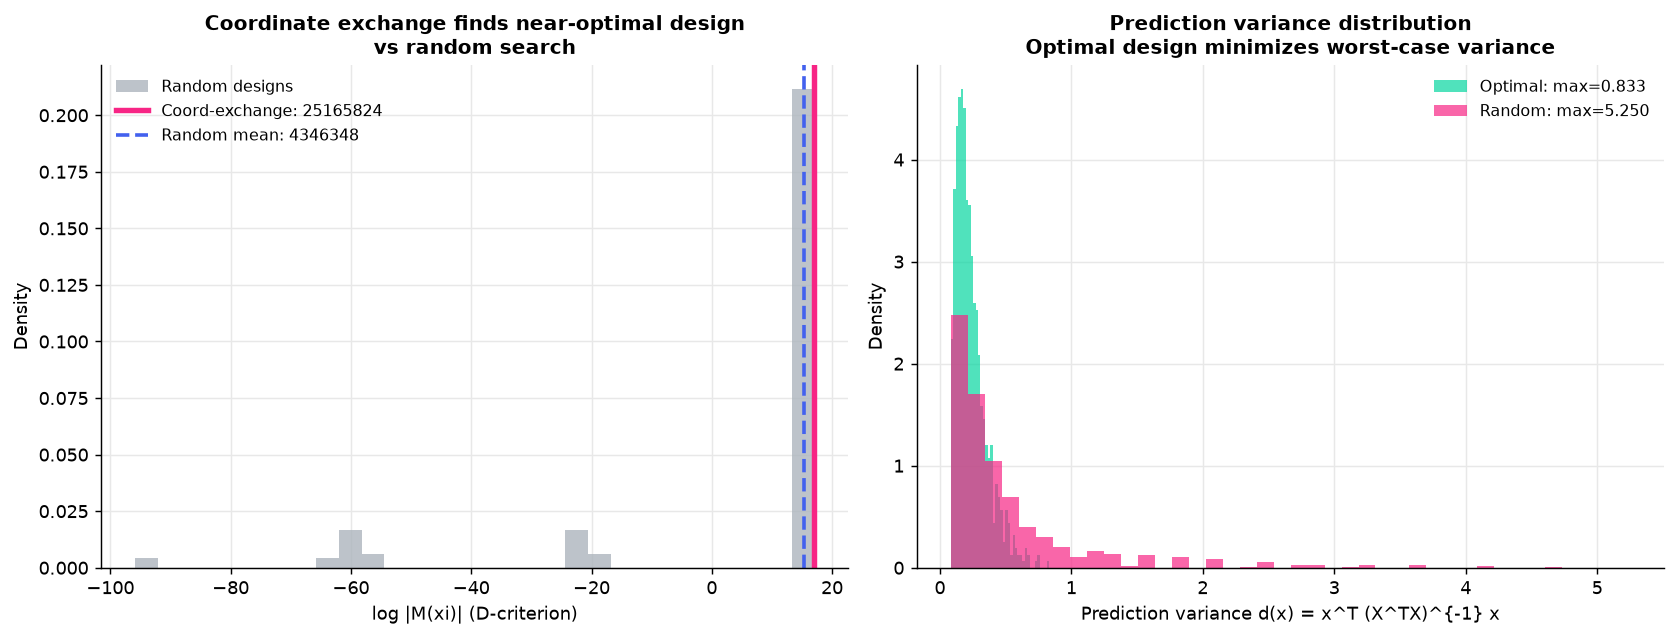


Max prediction variance: Optimal=0.8333  Random=5.2500
G-optimality improvement: 84.1%


In [2]:
# ── D-optimality: coordinate exchange algorithm ───────────────────────────
# Context: budget allows only 10 runs, but we have 3 factors (needs ~16 full factorial)
# Find the best 10-run design for a first-order model

np.random.seed(42)
n_runs = 12   # budget
k_factors = 3
# Model: y = b0 + b1*x1 + b2*x2 + b3*x3 + b12*x1x2 + b13*x1x3 + b23*x2x3

def model_matrix(X):
    n = len(X)
    x1, x2, x3 = X[:,0], X[:,1], X[:,2]
    return np.column_stack([np.ones(n), x1, x2, x3, x1*x2, x1*x3, x2*x3])

def d_criterion(X):
    M = model_matrix(X)
    MtM = M.T @ M
    try:
        return np.linalg.det(MtM)
    except:
        return 0.0

# Candidate set: all +-1 combinations (full 2^3)
candidates = np.array(list(product([-1,1], repeat=k_factors)), dtype=float)

# Coordinate exchange algorithm
def coordinate_exchange(n_runs, candidates, n_restarts=20):
    best_det = -np.inf; best_X = None
    for restart in range(n_restarts):
        # Random start
        idx = np.random.choice(len(candidates), n_runs, replace=True)
        X = candidates[idx].copy()
        improved = True
        while improved:
            improved = False
            for i in range(n_runs):
                curr_det = d_criterion(X)
                best_cand_idx = None
                for j, cand in enumerate(candidates):
                    X_try = X.copy(); X_try[i] = cand
                    new_det = d_criterion(X_try)
                    if new_det > curr_det:
                        curr_det = new_det
                        best_cand_idx = j
                if best_cand_idx is not None:
                    X[i] = candidates[best_cand_idx]; improved = True
        det_val = d_criterion(X)
        if det_val > best_det:
            best_det = det_val; best_X = X.copy()
    return best_X, best_det

print('Running coordinate exchange algorithm...')
X_opt, det_opt = coordinate_exchange(n_runs, candidates, n_restarts=30)

# Compare with random design and full 2^3 (8 runs)
dets_random = [d_criterion(candidates[np.random.choice(len(candidates), n_runs, replace=True)])
               for _ in range(200)]
X_full23 = candidates[:8]
det_full23 = d_criterion(X_full23)

print(f'\nD-criterion comparison (n_runs={n_runs}):')
print(f'  Full 2^3 (8 runs):        det = {det_full23:.1f}')
print(f'  Random design (mean/max): det = {np.mean(dets_random):.1f} / {np.max(dets_random):.1f}')
print(f'  Coordinate exchange opt:  det = {det_opt:.1f}')

p_params = 7  # 1 + 3 + 3
d_eff = (det_opt / max(dets_random))**(1/p_params) * 100
print(f'\nD-efficiency vs best random: {d_eff:.1f}%')

# Print optimal design
df_opt = pd.DataFrame(X_opt, columns=['x1','x2','x3'])
df_opt['Run'] = np.arange(1, n_runs+1)
print(f'\nOptimal {n_runs}-run design:')
print(df_opt.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution of D-criterion for random designs vs optimal
dets_pos = [d for d in dets_random if d > 0]
axes[0].hist(np.log(np.array(dets_pos)), bins=30, color='#adb5bd', alpha=0.8,
             density=True, label='Random designs')
axes[0].axvline(np.log(max(det_opt, 1e-300)), color='#f72585', lw=3, label=f'Coord-exchange: {det_opt:.0f}')
axes[0].axvline(np.log(max(np.mean(dets_random), 1e-300)), color='#4361ee', lw=2, linestyle='--',
                label=f'Random mean: {np.mean(dets_random):.0f}')
axes[0].set_xlabel('log |M(xi)| (D-criterion)')
axes[0].set_ylabel('Density')
axes[0].set_title('Coordinate exchange finds near-optimal design\nvs random search')
axes[0].legend(fontsize=9)

# Variance of prediction over design region
from itertools import product as iproduct
x_grid_1d = np.linspace(-1, 1, 15)
grid_pts = np.array(list(iproduct(x_grid_1d, x_grid_1d, x_grid_1d)))

def pred_variance(X_design, x_pred):
    M = model_matrix(X_design)
    MtM_inv = np.linalg.pinv(M.T @ M)
    Xp = model_matrix(x_pred.reshape(1,-1))[0]
    return float(Xp @ MtM_inv @ Xp)

var_opt = np.array([pred_variance(X_opt, pt) for pt in grid_pts])
X_random_best = candidates[np.random.choice(len(candidates), n_runs, replace=True)]
var_rand = np.array([pred_variance(X_random_best, pt) for pt in grid_pts])

axes[1].hist(var_opt, bins=40, alpha=0.7, color='#06d6a0', density=True, label=f'Optimal: max={var_opt.max():.3f}')
axes[1].hist(var_rand, bins=40, alpha=0.7, color='#f72585', density=True, label=f'Random: max={var_rand.max():.3f}')
axes[1].set_xlabel('Prediction variance d(x) = x^T (X^TX)^{-1} x')
axes[1].set_ylabel('Density')
axes[1].set_title('Prediction variance distribution\nOptimal design minimizes worst-case variance')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nMax prediction variance: Optimal={var_opt.max():.4f}  Random={var_rand.max():.4f}')
print(f'G-optimality improvement: {(1-var_opt.max()/var_rand.max())*100:.1f}%')

## Summary: which criterion to use?

| Criterion | Optimize | Best when |
|---|---|---|
| **D-optimal** | $\det(X^\top X)$ | Estimating all parameters well |
| **A-optimal** | $\text{tr}((X^\top X)^{-1})$ | Average SE across all parameters |
| **I-optimal** | $\int \text{Var}(\hat{y}) d\mu$ | Prediction over a region (RSM) |
| **G-optimal** | $\max \text{Var}(\hat{y})$ | Minimax prediction; equals D by equivalence theorem |
| **c-optimal** | $c^\top (X^\top X)^{-1} c$ | One specific linear combination (contrast) |

## Course summary

```
01 Fisher's 3 principles         -> Foundation of all experimental design
02 RCBD / Latin Square           -> Remove nuisance variation with blocking
03 2^k Factorial                 -> Estimate main effects + interactions
04 2^(k-p) Fractional            -> Screen many factors cheaply; resolution/aliasing
05 Response Surface (CCD/BBD)    -> Find the optimum; quadratic model
06 Sequential testing (SPRT/GSD) -> Stop early safely; valid inference at any time
07 Multi-Armed Bandits           -> Adaptive allocation; maximize welfare
08 Online Experiments            -> Network effects, switchback, CUPED
09 Optimal Design                -> Custom designs; information matrix; coordinate exchange
```

**Key reference chain:**
Fisher (1935) → Box & Wilson (1951, RSM) → Kiefer & Wolfowitz (1960, optimal design)
→ O'Brien & Fleming (1979, GSD) → Auer et al. (2002, UCB) → Johari et al. (2017, mSPRT)
→ Kohavi, Tang & Xu (2020, online experiments)